# **Point-in-time compliance breach exits**

**Mechanics:** The live book (FCF quality, 10% name cap, SPY 200-day SMA → cash) screens AAOIFI ratios at **month-end**. A 10-Q can land mid-month. Until the next rebalance, the fund can still own a name that no longer passes debt / cash / receivables tests. This notebook defines a forced-exit lag and measures the cost.

**White-paper focus:** Operational exit rules for losing compliance — extra turnover, tracking error versus waiting until month-end, and how many days the book stays non-compliant under a strict Sharia process.

**Frozen from 07–09:** FCF top-half by FCF/sales, cap-weighted, `name_cap=0.10`, whole-NAV SMA-to-cash. No ROIC mix, no SUE, no dual-momentum sleeve weight.

**Three lags**

| Lag | When we sell a failed name | Trade-date convention |
| --- | --- | --- |
| `month_end` | Next scheduled rebalance (status quo) | No intra-month trade |
| `same_day` | First session on or after the fail is known | Weights change that morning (close-to-close) |
| `next_open` | Session **after** that | One extra day of the name |

Cuts are **sticky** until the next month-end rebalance. We do not buy the name back on a bounce.

**Two monitors**

1. **Filings (ops rule).** Re-screen when a new `filed_date` is known. Denominator is the last 24-month market cap, nudged by about 1/24 of the spot move since the last snapshot.
2. **Daily (strict).** Also walk the price path between rebalances. AAOIFI uses a 24-month average, so this should rarely flip a name that was not already near the 30% / 30% / 70% lines.

**Kill-style reading (same 2020–2022 train / 2023–2024 test):** a lag fails if it makes 2022 more than 5 points worse than SPUS, or 2023 more than 15 points worse than always-on FCF. Those bars were built for the SMA. Here they are a sanity check: an exit rule should not blow up the book.

**Decision we want:** which lag is the live compliance rule — and is daily price monitoring worth running, or is filing-date the whole story?


## Setup

Reuse paper 07 metrics and prices. Engine is the paper 09 live book.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import display


def resolve_notebook_dir() -> Path:
    candidates = [Path.cwd()]
    candidates.append(
        Path.home() / "Documents/Development/Monterey-Finance/Research/papers/10-compliance-exits"
    )
    for path in candidates:
        try:
            resolved = path.resolve()
        except OSError:
            continue
        if resolved.is_dir() and (resolved / "code.ipynb").exists():
            return resolved
    return Path.cwd()


NB_DIR = resolve_notebook_dir()
os.chdir(NB_DIR)

REPO_ROOT = NB_DIR.parents[2]
RESEARCH_ROOT = NB_DIR.parents[1]
PAPER07 = RESEARCH_ROOT / "papers" / "07-book-construction"
HQ_ROOT = REPO_ROOT.parent / "halalquant"
PIP_DEPS = ["matplotlib", "pyarrow", "duckdb"]

if HQ_ROOT.is_dir() and (HQ_ROOT / "pyproject.toml").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", f"{HQ_ROOT}[cache]"],
        cwd=str(NB_DIR),
        check=False,
    )
    if str(HQ_ROOT) not in sys.path:
        sys.path.insert(0, str(HQ_ROOT))
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + PIP_DEPS, cwd=str(NB_DIR), check=False)
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

import importlib
import sleeves
import sleeves.backtest
import sleeves.book
import sleeves.exits
import sleeves.lab

importlib.reload(sleeves.exits)
importlib.reload(sleeves.backtest)
importlib.reload(sleeves.book)
importlib.reload(sleeves.lab)
importlib.reload(sleeves)

os.environ.setdefault(
    "HALALQUANT_SEC_UA",
    "Monterey Finance Research halalquant/0.1.0 research@montereyfinance.com",
)

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sleeves import FrozenRules, Lab, calc_performance_stats
from sleeves.backtest import holdings_to_weights, run_weight_schedule
from sleeves.exits import (
    apply_breach_exits,
    detect_breaches,
    extra_turnover,
    noncompliant_exposure,
)
from sleeves.prices import spy_sma_risk_on
from sleeves.universe import apply_sector_screen, load_sp500_tickers

warnings.filterwarnings("ignore", category=FutureWarning)

START = "2019-12-19"
END = "2024-12-31"
TRAIN_START, TRAIN_END = "2020-01-01", "2022-12-31"
TEST_START, TEST_END = "2023-01-01", "2024-12-31"
RISK_FREE_RATE = 0.02
NAME_CAP = 0.10
ENGINE = {"fcf_quality": 1.0}
KILL_2022_GAP = 0.05
KILL_2023_GAP = 0.15
BENCHMARKS = {"S&P 500": "SPY", "Halal (SPUS)": "SPUS"}
LAGS = ("month_end", "same_day", "next_open")
COST_BPS = 10.0

CACHE_DIR = PAPER07 / "cache"
FIG_DIR = NB_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"notebook dir: {NB_DIR}")
print(f"engine: FCF 100%  name_cap={NAME_CAP:.0%}  SMA-to-cash  breach lags {LAGS}")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


notebook dir: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/10-compliance-exits
engine: FCF 100%  name_cap=10%  SMA-to-cash  breach lags ('month_end', 'same_day', 'next_open')


## Step 1 — Load the lab and the locked book


In [2]:
metrics = pd.read_parquet(CACHE_DIR / "metrics.parquet")
prices = pd.read_parquet(CACHE_DIR / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])

raw = load_sp500_tickers()
eligible, _, sector_map = apply_sector_screen(raw)
print(f"metrics {metrics.shape}  prices {prices.shape}  sector map {len(sector_map)}")

rules = FrozenRules().with_book(
    sleeve_weights=ENGINE,
    name_cap=NAME_CAP,
    throttle="spy_sma",
    collapse_share_classes=True,
    cost_bps=COST_BPS,
    risk_free_rate=RISK_FREE_RATE,
    rebalance_freq="ME",
    breach_exit="month_end",
    breach_monitor="filings",
)
lab = Lab.from_frames(metrics, prices, rules=rules, start=START, end=END)

print("Running locked book (month-end compliance) …", flush=True)
base_ret, base_log = lab.book().run(start=START)
print(f"rebalance rows {len(base_log):,}  return days {len(base_ret):,}")

bench_px = (
    prices[prices["symbol"].isin(BENCHMARKS.values())]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
bench_ret = bench_px.pct_change(fill_method=None)
spy = bench_ret["SPY"].dropna()
spus = bench_ret["SPUS"].dropna()
spy = spy[(spy.index >= pd.Timestamp(START)) & (spy.index <= pd.Timestamp(END))]
spus = spus[(spus.index >= pd.Timestamp(START)) & (spus.index <= pd.Timestamp(END))]
print("Lab ready.")


metrics (25600, 21)  prices (778360, 8)  sector map 502
Running locked book (month-end compliance) …
rebalance rows 6,769  return days 1,266
Lab ready.


## Step 2 — When do held names fail?

Walk each month-end holding spell. A **filing** event is a new 10-Q/K whose ratios fail before the next rebalance. A **price** event is the same spell failing on the 24-month market-cap path with no new filing.


In [3]:
panel = lab.price_panel()
spy_px = lab.spy_series()
window = lab.rules.dual_momentum.sma_window
throttle_on = pd.Series(
    [spy_sma_risk_on(spy_px, dt, window) for dt in panel.index],
    index=pd.to_datetime(panel.index),
)
print("Detecting filing breaches …", flush=True)
events_f = detect_breaches(
    metrics, base_log, panel, rules=rules, monitor="filings", end=END, throttle_on=throttle_on
)
print("Detecting daily (filing + price) breaches …", flush=True)
events_d = detect_breaches(
    metrics, base_log, panel, rules=rules, monitor="daily", end=END, throttle_on=throttle_on
)

def census(events: pd.DataFrame, label: str) -> pd.Series:
    if events.empty:
        return pd.Series({"monitor": label, "events": 0, "names": 0, "mean_weight": np.nan})
    return pd.Series(
        {
            "monitor": label,
            "events": int(len(events)),
            "names": int(events["symbol"].nunique()),
            "mean_weight": float(events["weight"].mean()),
            "sum_weight": float(events["weight"].sum()),
            "debt_fails": int((events["reason"] == "debt ratio exceeds threshold").sum()),
            "cash_fails": int((events["reason"] == "cash ratio exceeds threshold").sum()),
            "recv_fails": int((events["reason"] == "receivables ratio exceeds threshold").sum()),
            "price_source": int((events["source"] == "price").sum()) if "source" in events else 0,
            "filing_source": int((events["source"] == "filing").sum()) if "source" in events else 0,
        }
    )

census_tbl = pd.DataFrame([census(events_f, "filings"), census(events_d, "daily")])
display(census_tbl)

if not events_f.empty:
    show = events_f.copy()
    show["detect_date"] = pd.to_datetime(show["detect_date"])
    by_year = show.groupby(show["detect_date"].dt.year).agg(
        events=("symbol", "size"),
        names=("symbol", "nunique"),
        mean_weight=("weight", "mean"),
    )
    display(by_year)
    top = (
        events_f.sort_values("weight", ascending=False)
        .head(15)[
            ["symbol", "detect_date", "weight", "reason", "debt_ratio", "cash_ratio", "receivables_ratio"]
        ]
        .copy()
    )
    display(top)

events_f.to_csv(NB_DIR / "filing_breaches.csv", index=False)
events_d.to_csv(NB_DIR / "daily_breaches.csv", index=False)
print("wrote filing_breaches.csv and daily_breaches.csv")


Detecting filing breaches …
Detecting daily (filing + price) breaches …


,monitor,events,names,mean_weight,sum_weight,debt_fails,cash_fails,recv_fails,price_source,filing_source
0,filings,25,19,0.005338,0.133439,19,6,0,0,25
1,daily,28,21,0.005088,0.142467,22,6,0,3,25


,events,names,mean_weight
detect_date,,,
2020,9,9,0.007225
2021,6,6,0.004415
2022,1,1,0.006617
2023,4,4,0.003029
2024,5,5,0.004638


,symbol,detect_date,weight,reason,debt_ratio,cash_ratio,receivables_ratio
3,ABBV,2020-02-21,0.015994,debt ratio exceeds threshold,0.465506,0.295115,0.335238
5,BMY,2020-02-24,0.013158,debt ratio exceeds threshold,0.527442,0.173730,0.246820
6,AMT,2020-02-25,0.013051,debt ratio exceeds threshold,0.304518,0.019004,0.024855
21,AMGN,2024-02-14,0.010721,debt ratio exceeds threshold,0.472413,0.159650,0.214003
12,GILD,2021-02-25,0.008718,debt ratio exceeds threshold,0.370269,0.087350,0.145033
11,CCI,2021-02-22,0.006955,debt ratio exceeds threshold,0.315240,0.003793,0.010840
17,FISV,2023-02-23,0.006786,debt ratio exceeds threshold,0.301152,0.012683,0.063090
15,ICE,2022-02-03,0.006617,cash ratio exceeds threshold,0.226695,2.410221,2.429897
9,ICE,2021-02-04,0.006418,debt ratio exceeds threshold,0.322819,0.038866,0.062877
7,FISV,2020-02-27,0.006266,debt ratio exceeds threshold,0.608661,0.000000,0.077323


wrote filing_breaches.csv and daily_breaches.csv


## Step 3 — Non-compliant days under each lag

For every detected fail, count trading days the name is still in the book after the fail is known. `month_end` holds until the next rebalance. `same_day` aims for zero extra days. `next_open` allows one session.


In [4]:
exp_rows = []
for lag in LAGS:
    exp = noncompliant_exposure(events_f, panel.index, lag)
    exp_rows.append(
        {
            "lag": lag,
            "events": int(len(events_f)),
            "name_days": float(exp["name_days"].sum()) if not exp.empty else 0.0,
            "weight_days": float(exp["weight_days"].sum()) if not exp.empty else 0.0,
            "one_way_turnover": extra_turnover(events_f) if lag != "month_end" else 0.0,
            "cost_drag_stub": (
                extra_turnover(events_f) * 2 * COST_BPS / 1e4 if lag != "month_end" else 0.0
            ),
        }
    )
exposure = pd.DataFrame(exp_rows)
display(exposure)


,lag,events,name_days,weight_days,one_way_turnover,cost_drag_stub
0,month_end,25,150.0,0.727908,0.000000,0.000000
1,same_day,25,0.0,0.000000,0.133439,0.000267
2,next_open,25,25.0,0.133439,0.133439,0.000267


## Step 4 — P&amp;L by lag

Same FCF schedule and SMA throttle. Only the intra-month weights change.


In [5]:
def sl(s, a, b):
    return s[(s.index >= pd.Timestamp(a)) & (s.index <= pd.Timestamp(b))].dropna()


def calendar_return(s, year):
    x = sl(s, f"{year}-01-01", f"{year}-12-31")
    return float((1 + x).prod() - 1) if not x.empty else np.nan


def to_series(frame):
    s = frame.dropna(subset=["return"]).set_index("date")["return"].astype(float)
    s.index = pd.to_datetime(s.index)
    return s.sort_index()


def score(s: pd.Series, label: str, lag: str) -> dict:
    full = sl(s, START, END)
    train = sl(s, TRAIN_START, TRAIN_END)
    test = sl(s, TEST_START, TEST_END)
    st = calc_performance_stats(full, label, rf=RISK_FREE_RATE)
    st_tr = calc_performance_stats(train, label, rf=RISK_FREE_RATE)
    st_te = calc_performance_stats(test, label, rf=RISK_FREE_RATE)
    return {
        "book": label,
        "lag": lag,
        "ret_2020": calendar_return(s, 2020),
        "ret_2022": calendar_return(s, 2022),
        "ret_2023": calendar_return(s, 2023),
        "ret_2024": calendar_return(s, 2024),
        "full_cagr": st["CAGR"],
        "full_vol": st["Volatility"],
        "full_sharpe": st["Sharpe"],
        "full_max_dd": st["Max Drawdown"],
        "full_calmar": st["Calmar"],
        "train_max_dd": st_tr["Max Drawdown"],
        "train_calmar": st_tr["Calmar"],
        "test_cagr": st_te["CAGR"],
        "test_max_dd": st_te["Max Drawdown"],
    }


def tracking_error(a: pd.Series, b: pd.Series) -> float:
    aligned = pd.concat([a, b], axis=1, keys=["a", "b"]).dropna()
    if aligned.empty:
        return np.nan
    return float((aligned["a"] - aligned["b"]).std() * np.sqrt(252))


weights_by_date = {}
for as_of, g in base_log.groupby("as_of"):
    key = pd.Timestamp(as_of).date()
    weights_by_date[key] = holdings_to_weights(g)

series_map = {}
rows = []
for lag in LAGS:
    label = f"FCF + SMA, exit {lag}"
    print(f"Running {label} …", flush=True)
    patched = apply_breach_exits(
        weights_by_date, events_f, panel.index, lag=lag, name_cap=NAME_CAP
    )
    ret = run_weight_schedule(
        lab.prices, patched, start=START, throttle_on=throttle_on
    )
    s = to_series(ret)
    series_map[label] = s
    rows.append(score(s, label, lag))

always_rules = FrozenRules().with_book(
    sleeve_weights=ENGINE,
    name_cap=NAME_CAP,
    throttle="off",
    collapse_share_classes=True,
    breach_exit="month_end",
)
always_lab = Lab.from_frames(metrics, prices, rules=always_rules, start=START, end=END)
print("Running always-on FCF (sanity) …", flush=True)
always_df, _ = always_lab.book().run(start=START)
always = to_series(always_df)
series_map["Always-on FCF (10% cap)"] = always
rows.append(score(always, "Always-on FCF (10% cap)", "n/a"))

for name, s in (("S&P 500", spy), ("Halal (SPUS)", spus)):
    series_map[name] = s
    rows.append(score(s, name, "benchmark"))

base_s = series_map["FCF + SMA, exit month_end"]
table = pd.DataFrame(rows)
table["te_vs_month_end"] = [
    np.nan if r["lag"] in {"month_end", "benchmark", "n/a"} else tracking_error(series_map[r["book"]], base_s)
    for _, r in table.iterrows()
]
table = table.merge(exposure, how="left", on="lag")

fcf_row = table.loc[table["book"] == "Always-on FCF (10% cap)"].iloc[0]
spus_row = table.loc[table["book"] == "Halal (SPUS)"].iloc[0]


def kill_reason(row) -> str:
    if row["lag"] in {"benchmark", "n/a"}:
        return ""
    reasons = []
    if pd.notna(row["ret_2022"]) and pd.notna(spus_row["ret_2022"]):
        if row["ret_2022"] < spus_row["ret_2022"] - KILL_2022_GAP:
            reasons.append("2022 >5ppt worse than SPUS")
    if pd.notna(row["train_max_dd"]) and pd.notna(spus_row["train_max_dd"]):
        if row["train_max_dd"] < spus_row["train_max_dd"]:
            reasons.append("train max DD worse than SPUS")
    if pd.notna(row["ret_2023"]) and pd.notna(fcf_row["ret_2023"]):
        if row["ret_2023"] < fcf_row["ret_2023"] - KILL_2023_GAP:
            reasons.append("2023 >15ppt worse than always-on FCF")
    return "; ".join(reasons)


table["kill"] = table.apply(kill_reason, axis=1)
table["pass"] = table["kill"] == ""
show = table.copy()
for c in (
    "ret_2020", "ret_2022", "ret_2023", "ret_2024",
    "full_cagr", "full_vol", "full_max_dd", "train_max_dd", "test_cagr", "test_max_dd",
    "te_vs_month_end", "weight_days", "one_way_turnover", "cost_drag_stub",
):
    if c in show.columns:
        show[c] = show[c].map(lambda x: x if pd.isna(x) else f"{x:.2%}" if abs(x) < 10 else f"{x:.2f}")
for c in ("full_sharpe", "full_calmar", "train_calmar"):
    if c in show.columns:
        show[c] = show[c].map(lambda x: "" if pd.isna(x) else f"{x:.2f}")
display(show)

table.to_csv(NB_DIR / "exit_lag_results.csv", index=False)
print("wrote exit_lag_results.csv")


Running FCF + SMA, exit month_end …
Running FCF + SMA, exit same_day …
Running FCF + SMA, exit next_open …
Running always-on FCF (sanity) …


,book,lag,ret_2020,ret_2022,ret_2023,ret_2024,full_cagr,full_vol,full_sharpe,full_max_dd,...,test_cagr,test_max_dd,te_vs_month_end,events,name_days,weight_days,one_way_turnover,cost_drag_stub,kill,pass
0,"FCF + SMA, exit month_end",month_end,32.16%,0.97%,35.61%,20.76%,23.29%,13.56%,1.46,-9.04%,...,28.10%,-7.79%,NaN,25.0,150.0,72.79%,0.00%,0.00%,,True
1,"FCF + SMA, exit same_day",same_day,32.19%,0.94%,35.60%,20.87%,23.32%,13.56%,1.47,-9.04%,...,28.15%,-7.79%,0.04%,25.0,0.0,0.00%,13.34%,0.03%,,True
2,"FCF + SMA, exit next_open",next_open,32.28%,0.97%,35.61%,20.85%,23.34%,13.56%,1.47,-9.04%,...,28.15%,-7.79%,0.04%,25.0,25.0,13.34%,13.34%,0.03%,,True
3,Always-on FCF (10% cap),n/a,24.88%,-22.91%,30.25%,20.76%,14.56%,21.62%,0.64,-29.47%,...,25.53%,-9.48%,NaN,NaN,NaN,NaN,NaN,NaN,,True
4,S&P 500,benchmark,18.33%,-18.18%,26.18%,25.34%,14.75%,20.94%,0.67,-33.72%,...,25.93%,-9.97%,NaN,NaN,NaN,NaN,NaN,NaN,,True
5,Halal (SPUS),benchmark,25.68%,-22.76%,34.20%,27.67%,17.78%,21.58%,0.77,-30.80%,...,31.11%,-11.46%,NaN,NaN,NaN,NaN,NaN,NaN,,True


wrote exit_lag_results.csv


## Step 5 — Paths


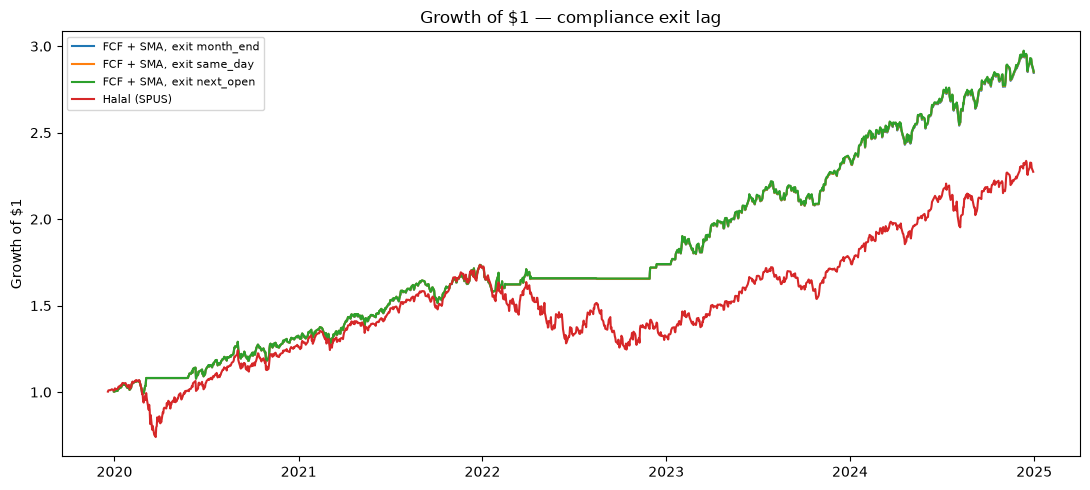

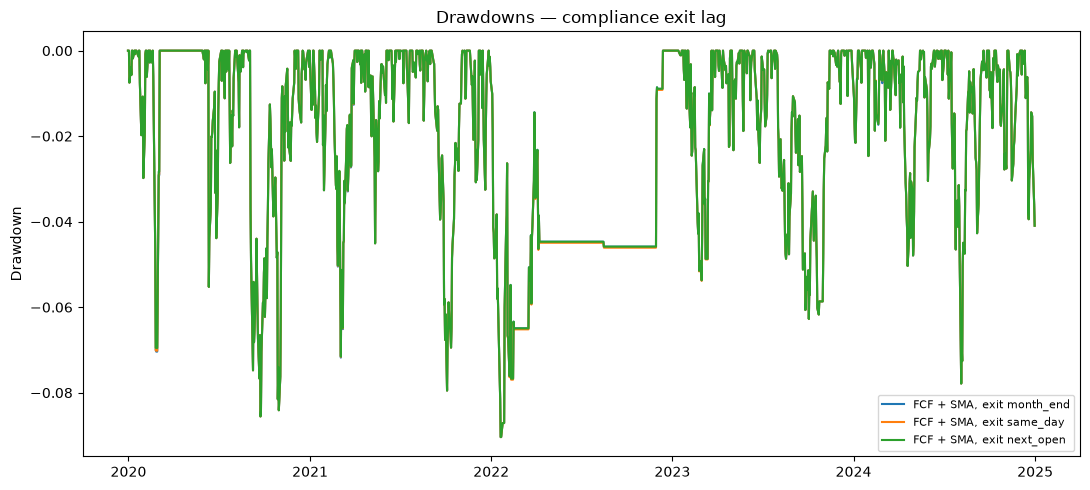

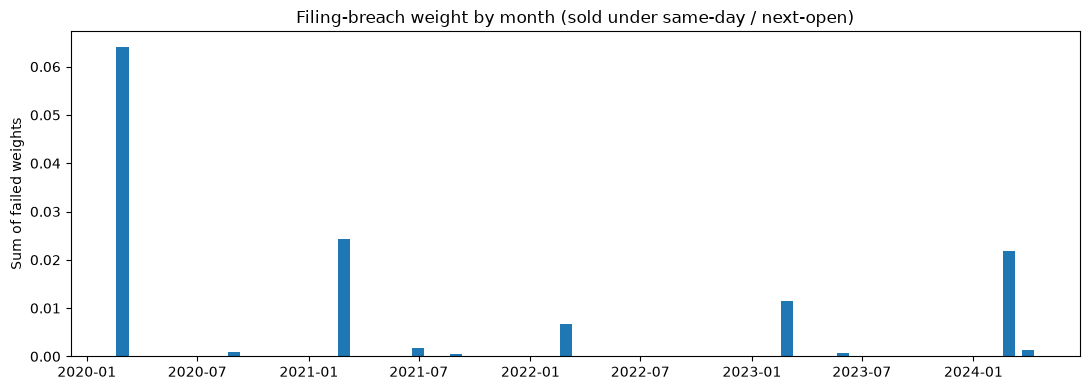

In [6]:
plot_keys = [
    "FCF + SMA, exit month_end",
    "FCF + SMA, exit same_day",
    "FCF + SMA, exit next_open",
    "Halal (SPUS)",
]
plot_keys = [k for k in plot_keys if k in series_map]

fig, ax = plt.subplots(figsize=(11, 5))
for k in plot_keys:
    eq = (1 + sl(series_map[k], START, END)).cumprod()
    ax.plot(eq.index, eq.values, label=k)
ax.set_title("Growth of $1 — compliance exit lag")
ax.set_ylabel("Growth of $1")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "equity-curves.png", dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for k in plot_keys:
    if k == "Halal (SPUS)":
        continue
    eq = (1 + sl(series_map[k], START, END)).cumprod()
    dd = eq / eq.cummax() - 1
    ax.plot(dd.index, dd.values, label=k)
ax.set_title("Drawdowns — compliance exit lag")
ax.set_ylabel("Drawdown")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "drawdowns.png", dpi=140)
plt.show()

if not events_f.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    ev = events_f.copy()
    ev["detect_date"] = pd.to_datetime(ev["detect_date"])
    monthly = ev.set_index("detect_date").resample("ME")["weight"].sum()
    ax.bar(monthly.index, monthly.values, width=20)
    ax.set_title("Filing-breach weight by month (sold under same-day / next-open)")
    ax.set_ylabel("Sum of failed weights")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "breach-weight.png", dpi=140)
    plt.show()


## Step 6 — Pick

The live compliance rule is the lag that (1) cuts non-compliant days, (2) does not fail the 2022/2023 bars, and (3) does not add material tracking error or turnover versus month-end.

If filings are rare and daily price flips add almost nothing, **next_open** is the honest ops default: SEC stamps are often after the close, so same-day is slightly optimistic.

If month-end already drops the name at the next snapshot and intra-month events are tiny, the P&amp;L gap will be small. That is still a process decision, not a return decision.


In [7]:
cands = table[table["lag"].isin(LAGS)].copy()
print(cands[["book", "lag", "full_cagr", "full_max_dd", "full_calmar", "te_vs_month_end", "name_days", "pass", "kill"]].to_string(index=False))

# Prefer next_open if it matches month-end risk and clears non-compliant days.
alive = cands[cands["pass"]].copy()
if alive.empty:
    pick = "month_end"
    why = "no lag passed the sanity bars; keep status quo"
else:
    # smallest non-compliant weight-days, then closest Calmar to month_end
    me_calmar = float(cands.loc[cands["lag"] == "month_end", "full_calmar"].iloc[0])
    alive["calmar_gap"] = (alive["full_calmar"] - me_calmar).abs()
    alive = alive.sort_values(["weight_days", "calmar_gap"])
    pick = str(alive.iloc[0]["lag"])
    why = "fewest non-compliant weight-days among lags that pass the sanity bars"

print()
print(f"PICK: {pick}")
print(f"why: {why}")
print()
print("Live rule going forward:")
print("  FrozenRules().with_book(")
print("      sleeve_weights={'fcf_quality': 1.0},")
print("      name_cap=0.10,")
print("      throttle='spy_sma',")
print(f"      breach_exit={pick!r},")
print("      breach_monitor='filings',")
print("  )")


                     book       lag  full_cagr  full_max_dd  full_calmar  te_vs_month_end  name_days  pass kill
FCF + SMA, exit month_end month_end   0.232864    -0.090376     2.576619              NaN      150.0  True     
 FCF + SMA, exit same_day  same_day   0.233197    -0.090376     2.580297         0.000403        0.0  True     
FCF + SMA, exit next_open next_open   0.233436    -0.090376     2.582943         0.000442       25.0  True     

PICK: same_day
why: fewest non-compliant weight-days among lags that pass the sanity bars

Live rule going forward:
  FrozenRules().with_book(
      sleeve_weights={'fcf_quality': 1.0},
      name_cap=0.10,
      throttle='spy_sma',
      breach_exit='same_day',
      breach_monitor='filings',
  )


## How to read the pick

- **Month-end** is what the backtests in papers 07–09 already did. The FCF selector never buys a name that fails on a rebalance date. The hole is the days *between* the 10-Q and that date.
- **Same-day** is the strictest P&amp;L. It assumes we can trade the session the filing is dated. Many EDGAR stamps are after hours.
- **Next-open** is the rule you can actually write in an ops manual: fail known after the close → sell at the next session → do not re-enter until the next month-end screen.
- Daily price monitoring is a robustness check. If it barely adds events, paper 15 (boundary monitoring) is the follow-up, not a second live switch.

**Not in this paper:** purification of impure income (11), round-trip costs at scale (12), or pre-emptive trims at 28–29% debt (15).
